[RunningCellMaskingGenerator](https://github.com/OpenGVLab/VideoMAEv2/blob/master/dataset/masking_generator.py#L80)

In [1]:
%matplotlib inline

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE" # tells OpenMP to not complain if it notices that two copies of OpenMP are loaded.

from IPython.display import Video
from IPython.display import Audio as play_audio
from torchvision.utils import make_grid
from torchcodec.encoders import VideoEncoder

def play_video(encoded_bytes):
    return Video(data=encoded_bytes.numpy().tobytes(),
                embed=True, width=640, height=360, mimetype="video/mp4")

import matplotlib.pyplot as plt

import sys
sys.path.append('../../../')

from pathlib import Path

%load_ext autoreload
%autoreload 2
    
from computer_vision.video_mae.dataset.transforms import GroupMultiScaleCrop, Stack, ToTorchFormatTensor, GroupNormalize
from computer_vision.video_mae.dataset.masking_generator import TubeMaskingGenerator, RunningCellMaskingGenerator, Cell

In [2]:
import math
import numbers
import warnings
import random

import numpy as np
import torch
import torchvision
import torchvision.transforms.functional as F
from PIL import Image, ImageOps

In [3]:
output_dirpath=Path('D:/results/ucf101/video_mae')
output_dirpath.mkdir(parents=True, exist_ok=True)
video_data=torch.load(output_dirpath/'extracted_video_data_numpy.pt', weights_only=False)
print(f'{type(video_data)=}, {video_data.shape}')
images=[Image.fromarray(video_data[vid,]) for vid in range(16)] # convert each frame to PIL.Image

input_mean = [0.485, 0.456, 0.406]
input_std = [0.229, 0.224, 0.225]

aug_op=GroupMultiScaleCrop(input_size=224, scales=[1, .875, .75, .66])
ret_imgs, label=aug_op((images, None))
aug_op=Stack(roll=False)
ret_imgs, label=aug_op((ret_imgs, label))
aug_op=ToTorchFormatTensor(div=True)
ret_imgs, label=aug_op((ret_imgs, label))
print(f"{type(ret_imgs)=}, {ret_imgs.shape=}, (min, max)=({ret_imgs.min().item()}, {ret_imgs.max().item()})")

aug_op=GroupNormalize(mean=input_mean, std=input_std)
ret_imgs, label=aug_op((ret_imgs, label))
print(f"{type(ret_imgs)=}, {ret_imgs.shape=}, (min, max)=({ret_imgs.min().item()}, {ret_imgs.max().item()})")

type(video_data)=<class 'numpy.ndarray'>, (16, 240, 320, 3)
type(ret_imgs)=<class 'torch.Tensor'>, ret_imgs.shape=torch.Size([48, 224, 224]), (min, max)=(0.0, 1.0)
type(ret_imgs)=<class 'torch.Tensor'>, ret_imgs.shape=torch.Size([48, 224, 224]), (min, max)=(-2.1179039478302, 2.640000104904175)


In [4]:
# self.decoder_mask_map_generator=RunningCellMaskingGenerator(args.window_size, args.decoder_mask_ratio)
window_size=(8,14,14)
decoder_mask_ratio=0.5
mask_gen=RunningCellMaskingGenerator(input_size=window_size, mask_ratio=decoder_mask_ratio)
mask_tubes=mask_gen()
print(f"{type(mask_tubes)=}, {mask_tubes.shape=}")

type(mask_tubes)=<class 'numpy.ndarray'>, mask_tubes.shape=(8, 196)


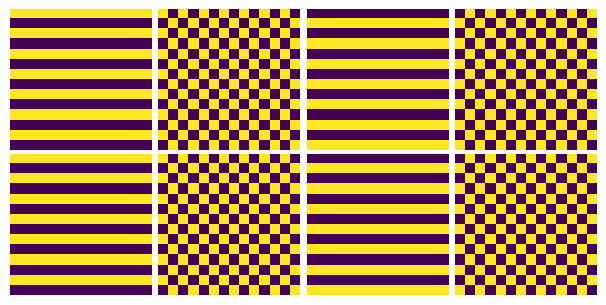

In [5]:
mask_tubes=mask_tubes.reshape(window_size)
fig, ax=plt.subplots(2,4,figsize=(6,3))
for i in range(2):
    for j in range(4):
        k=4*i+j
        ax[i,j].imshow(mask_tubes[k])#, cmap='gray')
        ax[i,j].axis('off')
plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=0.5)